# S&P 500 Model Comparison Analysis

Comparing three models trained to predict S&P 500 returns using macroeconomic features:
- **Random Forest** — ensemble of decision trees

- **Ridge Regression** — linear model with L2 regularisation
- **XGBoost** — gradient boosted trees

All models use the same 7 differenced/lagged features:
`CPI_Change_lag1`, `Rate_Change`, `GDP_Growth_lag2`, `Unemp_Change_lag1`, `USD_Change`, `VIX_Change`, `Credit_Spread_lag2`

**Train set:** 346 samples | **Test set:** 69 samples

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
base_dir = Path().resolve().parent
sys.path.append(str(base_dir))
MODEL_DIR = str(base_dir / "models")

## Load all saved results
Every training notebook saved its outputs using the same `save_evaluation()`, `save_shap()`, and `save_model()` functions — so the structure is consistent across all three models.

In [2]:
from utils.load_results import load_evaluations, load_shap_values, load_models, get_y_test

# load saved results, shap values, and models
results   = load_evaluations(MODEL_DIR)
shap_data = load_shap_values(MODEL_DIR)
models    = load_models(MODEL_DIR)
models_obj = load_models(MODEL_DIR)
y_test    = get_y_test(results)

Loaded 3 evaluations: ['rf', 'ridge', 'xgboost']
Loaded 3 SHAP files: ['rf', 'ridge', 'xgboost']
Loaded 3 models: ['rf', 'ridge', 'xgboost']
Loaded 3 models: ['rf', 'ridge', 'xgboost']


## Which model fits best?
A quick summary of all metrics before we look at any charts. This is the executive summary, this table tells the full story.

In [3]:
from src.metrics_table import print_metrics_table
print_metrics_table(results)

Model             R² Train    R² Test   RMSE Train    RMSE Test  MAE Train   MAE Test  Dir Train   Dir Test
rf                  0.5198     0.3486        2.828        4.051      2.133      3.170      78.61      73.91
ridge               0.3456     0.3225        3.302        4.131      2.488      3.213      73.41      71.01
xgboost             0.4545     0.3068        3.014        4.179      2.262      3.274      78.32      72.46


#### Key findings
- **RF has the best test R²** (0.349) and lowest test RMSE (4.051), but a noticeable train-test gap (0.52 → 0.35)
- **Ridge is the most consistent** — smallest gap between train and test (0.346 → 0.323)
- **XGBoost falls between the two** — moderate train performance

- All three models achieve **71–74% directional accuracy** on the test set, meaning they predict the correct sign of S&P 500 movement about 3 out of 4 times
- All test R² values are below 0.35 — these are modest fits, typical for financial return prediction

## How do they compare visually?
Numbers can be deceiving. Side-by-side bars make the train vs test gap immediately obvious.if one model has a tall train bar but a short test bar, it's memorising noise rather than learning patterns.

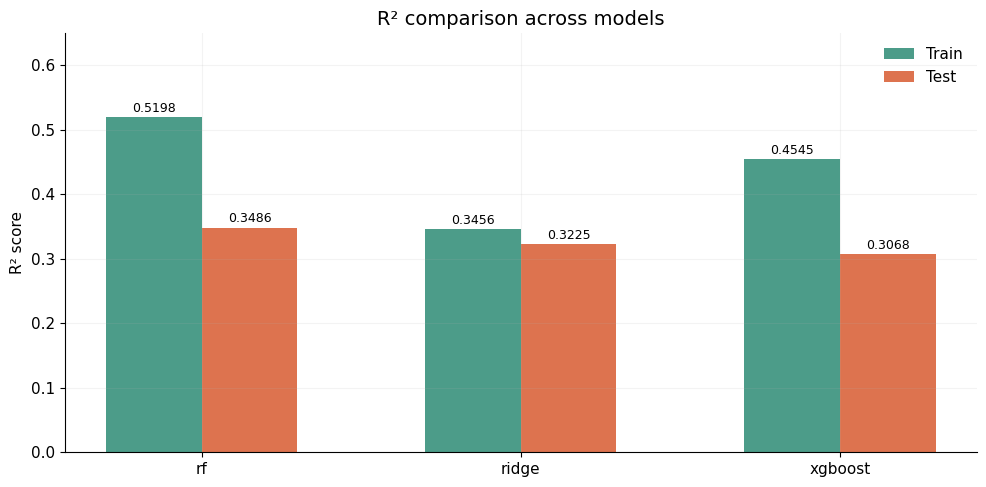

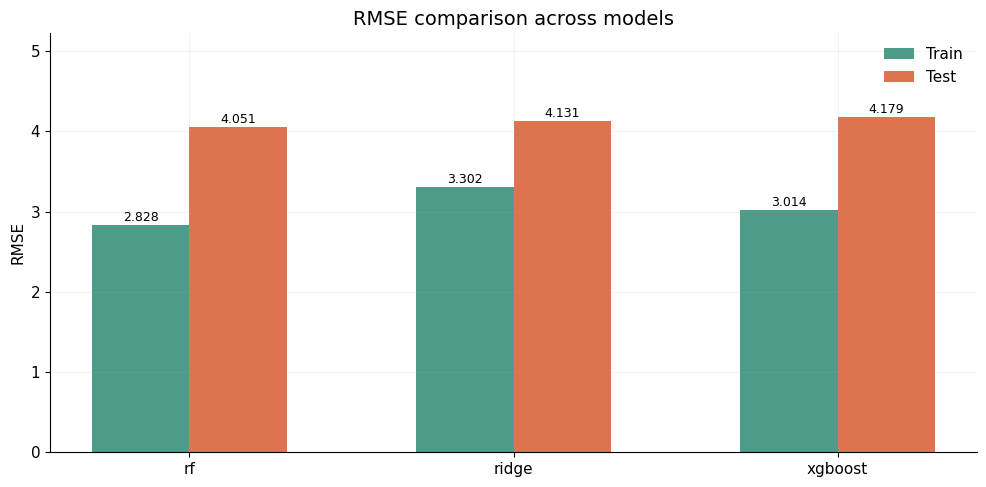

In [4]:
from src.compare_r2_rmse import compare_r2, compare_rmse
compare_r2(results)
compare_rmse(results)

## Are any models memorising noise?
The heatmap quantifies exactly how much each model degrades from train to test. Higher values (darker colors) mean more overfitting. This tells us whether the accuracy numbers from previos step can be trusted.

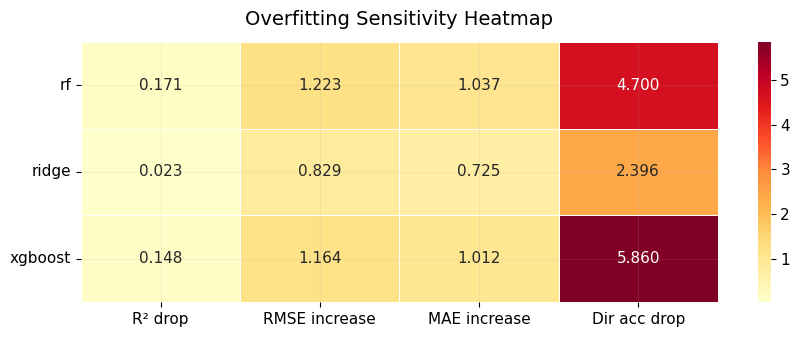

In [5]:
from src.compare_overfitting import compare_overfitting
compare_overfitting(results)

#### Key findings
- **RF and XGBoost both overfit significantly** — RF's R² drops by 0.17, XGBoost by 0.15. Both tree-based models memorise training patterns that don't fully generalise

- **Ridge is the most stable** — R² drops only 0.02 (0.346 → 0.323), nearly identical on train and test. The heavy regularisation (α=312.6) prevents overfitting at the cost of lower peak performance
- **RMSE tells the same story**: Ridge's RMSE increases least (0.83), while RF and XGBoost both increase by ~1.2
- **Despite overfitting, RF still wins on test** — it has the best test R² (0.349), best test RMSE (4.051), and best test MAE (3.170). Overfitting doesn't mean the model is bad, it means the train metrics are inflated
- **All test RMSE values are close** (4.05–4.18) — the practical difference between models is small

## What are they actually predicting, and where do they fail?

Instead of comparing raw predictions (which often overlap and are hard to read), focus on **residuals**.

**Residuals** are the difference between:
- what the model predicted  
- what actually happened  

Analysing residuals helps to:

- detect **systematic bias** (consistent over- or under-prediction)  
- identify **patterns in errors** across different conditions  
- understand **tail risk** (large or extreme errors) that summary metrics may hide  

This gives a clearer and more reliable view of model performance.
 Residuals reveal systematic biases, inconsistent error patterns, and tail-risk behaviour that summary metrics hide.

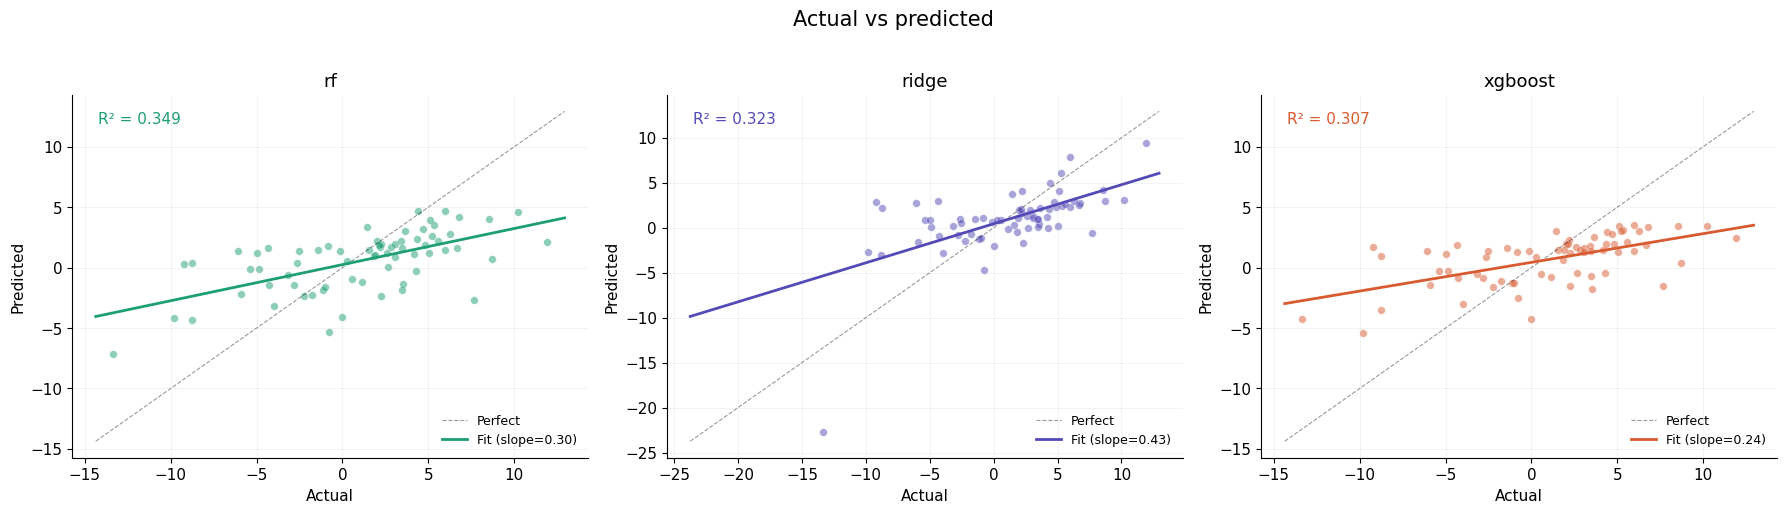

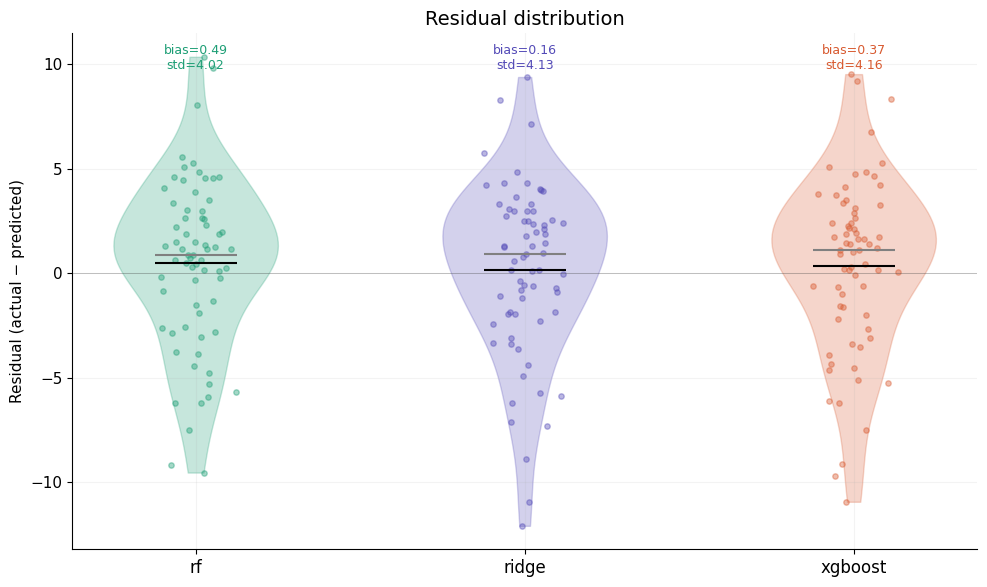

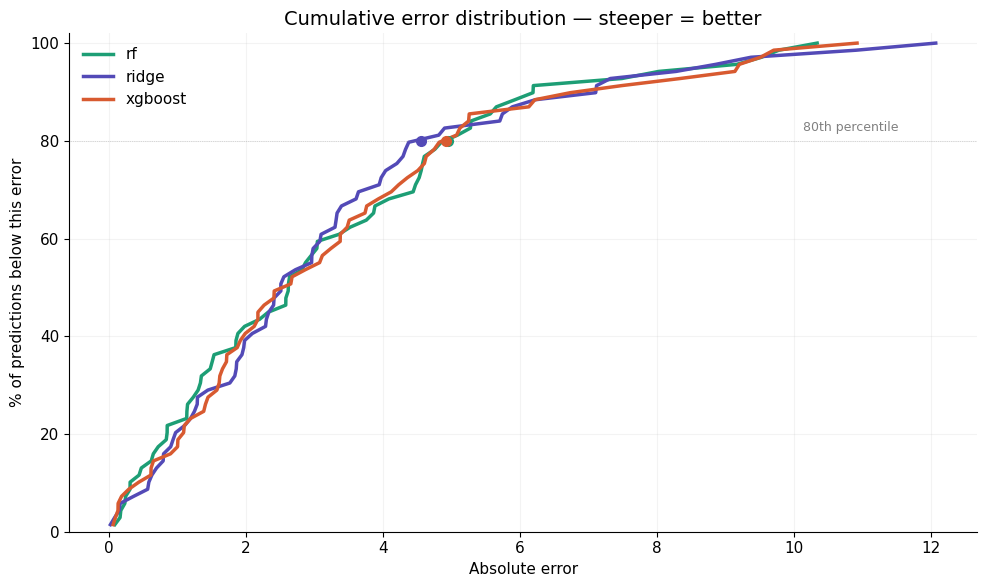

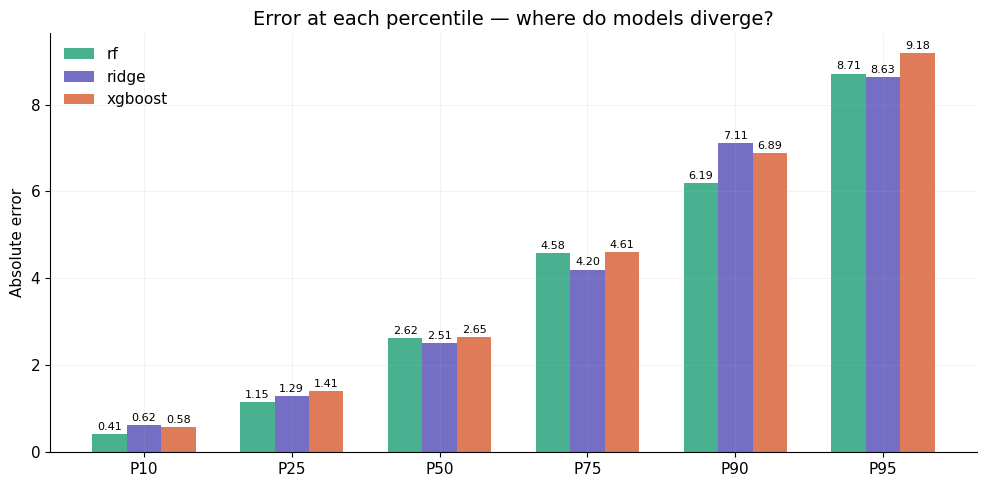


Model               Bias      Std     Skew  P50 err  P80 err  P95 err
rf                 0.488    4.021   -0.260    2.620    4.946    8.712
ridge              0.159    4.128   -0.671    2.509    4.552    8.628
xgboost            0.365    4.163   -0.460    2.655    4.923    9.179


In [6]:
from src.prediction import compare_predictions
compare_predictions(results, y_test)

#### Key findings
- **All three models have positive bias** — they slightly overpredict S&P 500 returns (RF bias: +0.49, Ridge: +0.16, XGBoost: +0.37)

- **Ridge has the lowest bias** but similar error spread to the others
- **Cumulative error curves** are nearly overlapping — at the 80th percentile, all models have nearly 4.5–5.0 absolute error
- **Tail risk is similar** — P95 errors range from 8.6 to 9.2 across models, meaning 1 in 20 predictions is off by ~9 percentage points
- The violin plots show all models have **left-skewed residuals** (negative skew), meaning occasional large underpredictions

## Which features matter, and do models agree?
SHAP values provide a unified importance measure that works across all model types — unlike raw feature importance which uses different units (impurity, coefficients, gain). The radar chart and rank table reveal whether the three architectures agree on which macro features drive S&P 500 predictions.

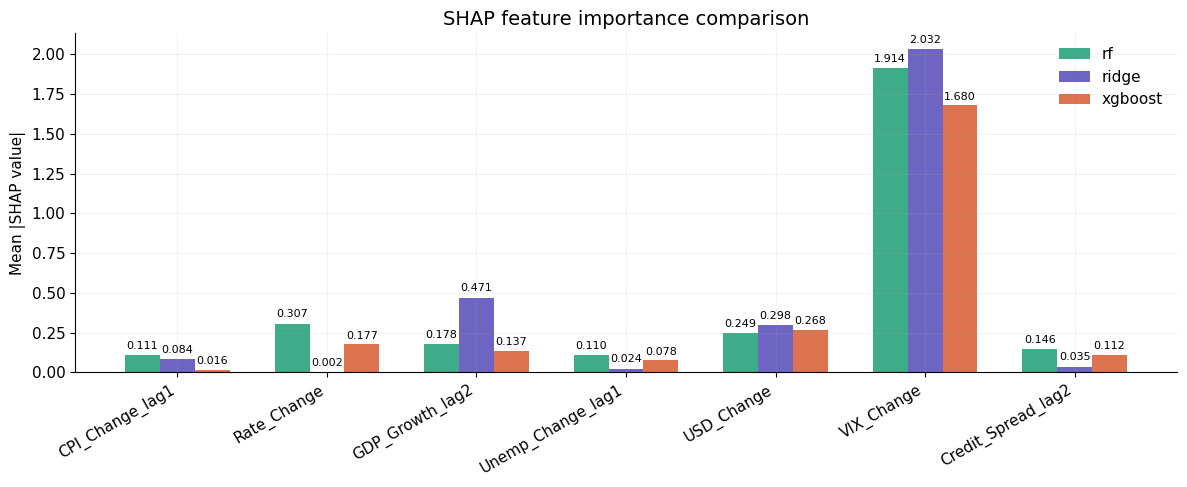

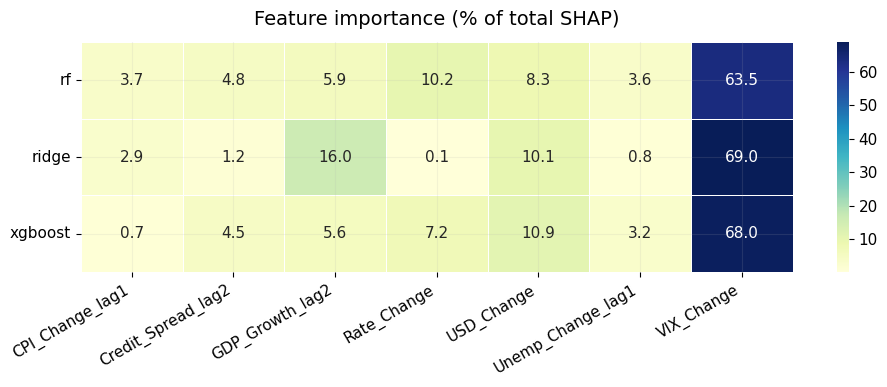

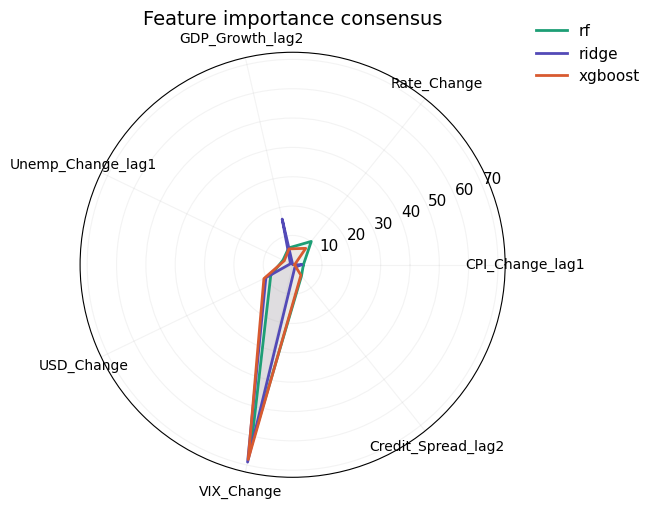


Feature ranking by SHAP (1 = most important)
                    rf  ridge  xgboost  Avg rank
VIX_Change           1      1        1       1.0
USD_Change           3      3        2       2.7
GDP_Growth_lag2      4      2        4       3.3
Rate_Change          2      7        3       4.0
Credit_Spread_lag2   5      5        5       5.0
CPI_Change_lag1      6      4        7       5.7
Unemp_Change_lag1    7      6        6       6.3



In [7]:
from src.compare_feature_importance import compare_feature_importance
compare_feature_importance(shap_data)

#### Key findings
- **VIX_Change is unanimously rank #1** across all three models — the market's fear gauge is the dominant predictor of S&P 500 returns
- **USD_Change and GDP_Growth_lag2** form a consistent second tier (avg rank 2.7 and 3.3)

- **Unemp_Change_lag1 is consistently least important** (avg rank 6.3) — lagged unemployment changes add minimal predictive value
- The radar chart shows RF and XGBoost have similar importance profiles, while Ridge distributes weight slightly more evenly
- VIX_Change SHAP value (~1.9) is roughly 6× larger than the next feature, showing that it has a much stronger influence than the rest.

## Are features the model learned actually useful on test data?
This is a critical diagnostic. Model importance is computed on training data. SHAP importance is computed on test data. If they agree, the feature is genuinely important. If a feature ranks high in training but low in SHAP, the model may have overfit to patterns in that feature that don't generalise.

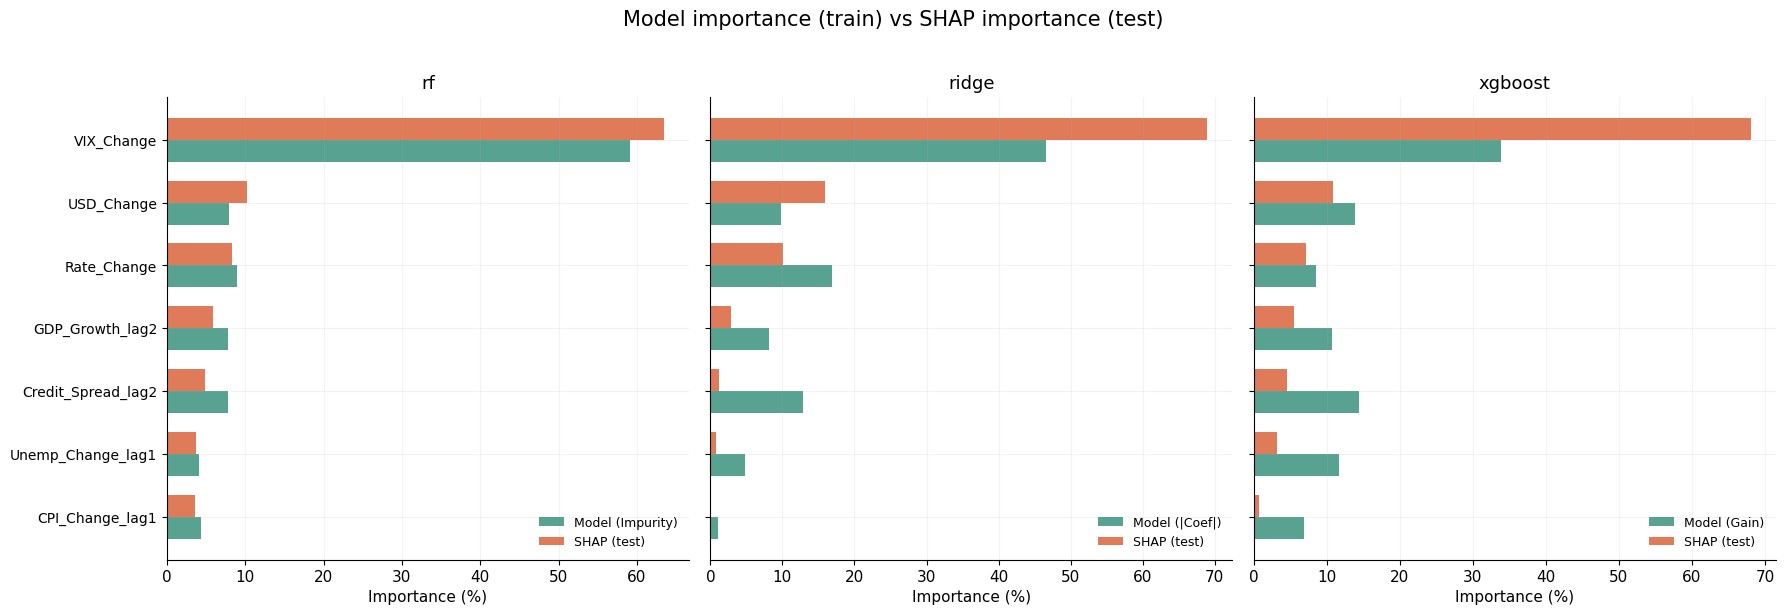

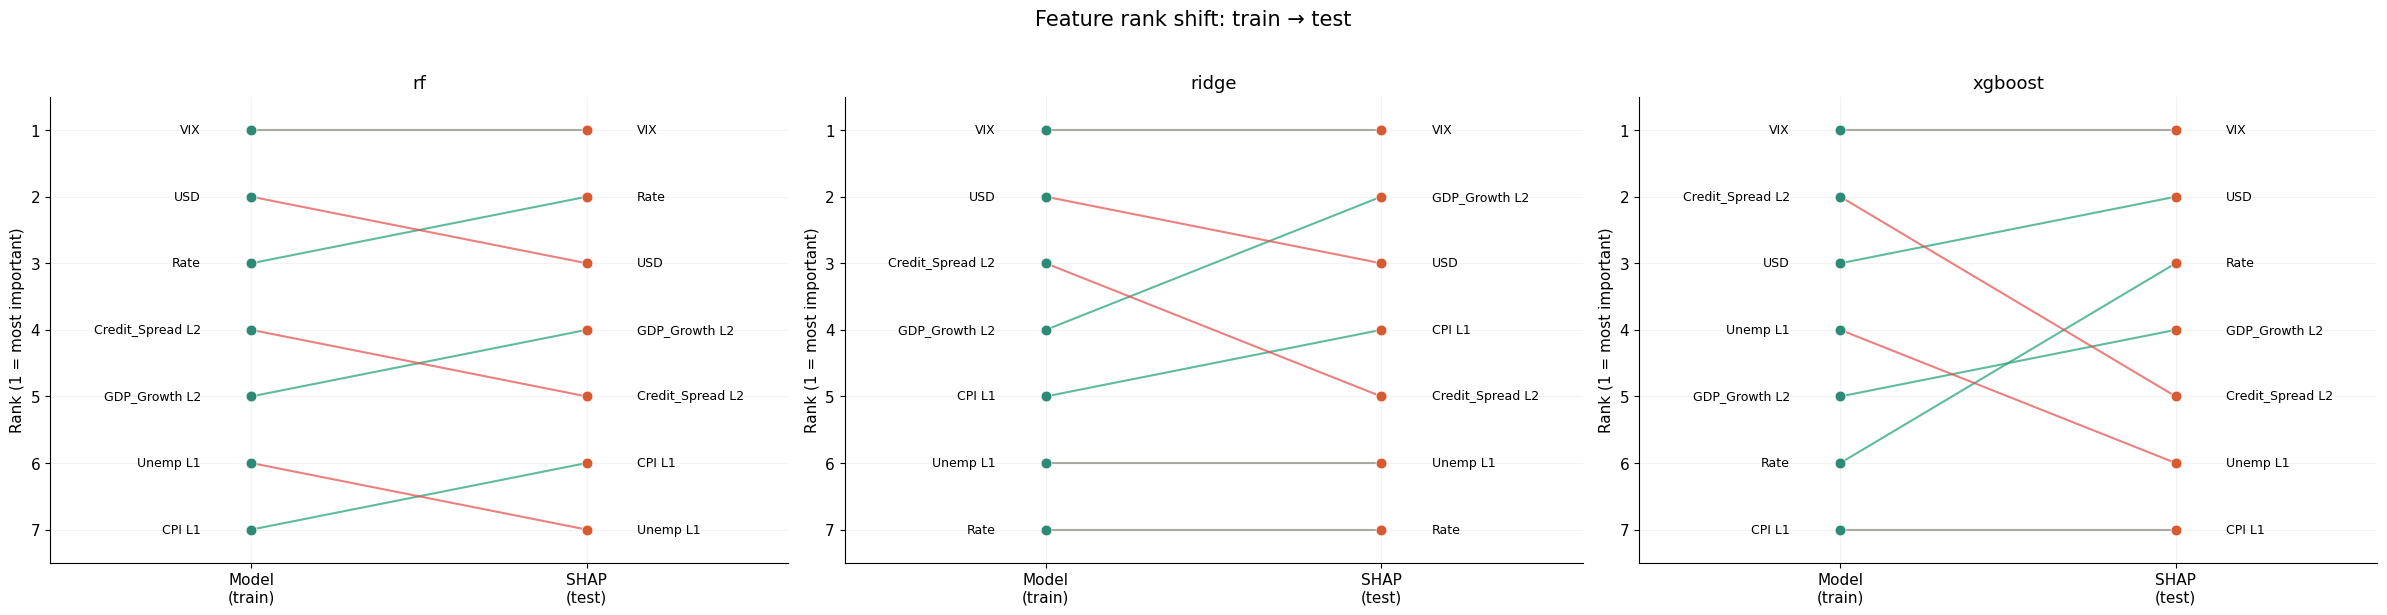


Feature importance: model (train) vs SHAP (test)

  rf (Impurity)
  Feature                    Train%  Rank   SHAP%  Rank  Shift   Flag
  --------------------------------------------------------------
  CPI_Change_lag1              4.1%    7    3.7%    6    +1       
  Rate_Change                  7.9%    3   10.2%    2    +1       
  GDP_Growth_lag2              7.8%    5    5.9%    4    +1       
  Unemp_Change_lag1            4.4%    6    3.6%    7    -1       
  USD_Change                   8.9%    2    8.3%    3    -1       
  VIX_Change                  59.1%    1   63.5%    1    +0       
  Credit_Spread_lag2           7.8%    4    4.8%    5    -1       

  ridge (|Coef|)
  Feature                    Train%  Rank   SHAP%  Rank  Shift   Flag
  --------------------------------------------------------------
  CPI_Change_lag1              8.2%    5    2.9%    4    +1       
  Rate_Change                  1.0%    7    0.1%    7    +0       
  GDP_Growth_lag2              9.8%    4  

In [8]:
from src.compare_importance_vs_shap import compare_importance_vs_shap
compare_importance_vs_shap(shap_data, models_obj)
 

### Key findings
- **VIX_Change is consistently #1** in both train importance and test SHAP across all three models — this is a genuine, robust finding, not an overfitting artifact

- **Feature ranks are remarkably stable** between train and test — no feature shifts more than 1-2 positions in RF, confirming the models learned real patterns
- **Train-test correlation is high for RF** — what the model learns on training data translates well to test data
- **Ridge shows the largest shifts**: Credit_Spread drops from train rank #3 to SHAP rank #5, and Rate_Change drops from #7 to a similar low position — Ridge's heavy regularisation (α=312.6) may be suppressing features that matter on test data
- **XGBoost shows Credit_Spread dropping** from train rank #2 to SHAP rank #5 — this feature may capture training-specific patterns
- **Practical implication**: the models are learning genuine macro-return relationships, not overfitting. VIX dominance (~60-69% of total SHAP) is real — these models are fundamentally VIX-driven predictors with minor corrections from other macro features

## Do models agree on individual predictions?
High correlation between two models means they're making similar predictions — ensembling them won't add much value. Low correlation means the models capture different patterns, and combining them could improve overall performance.

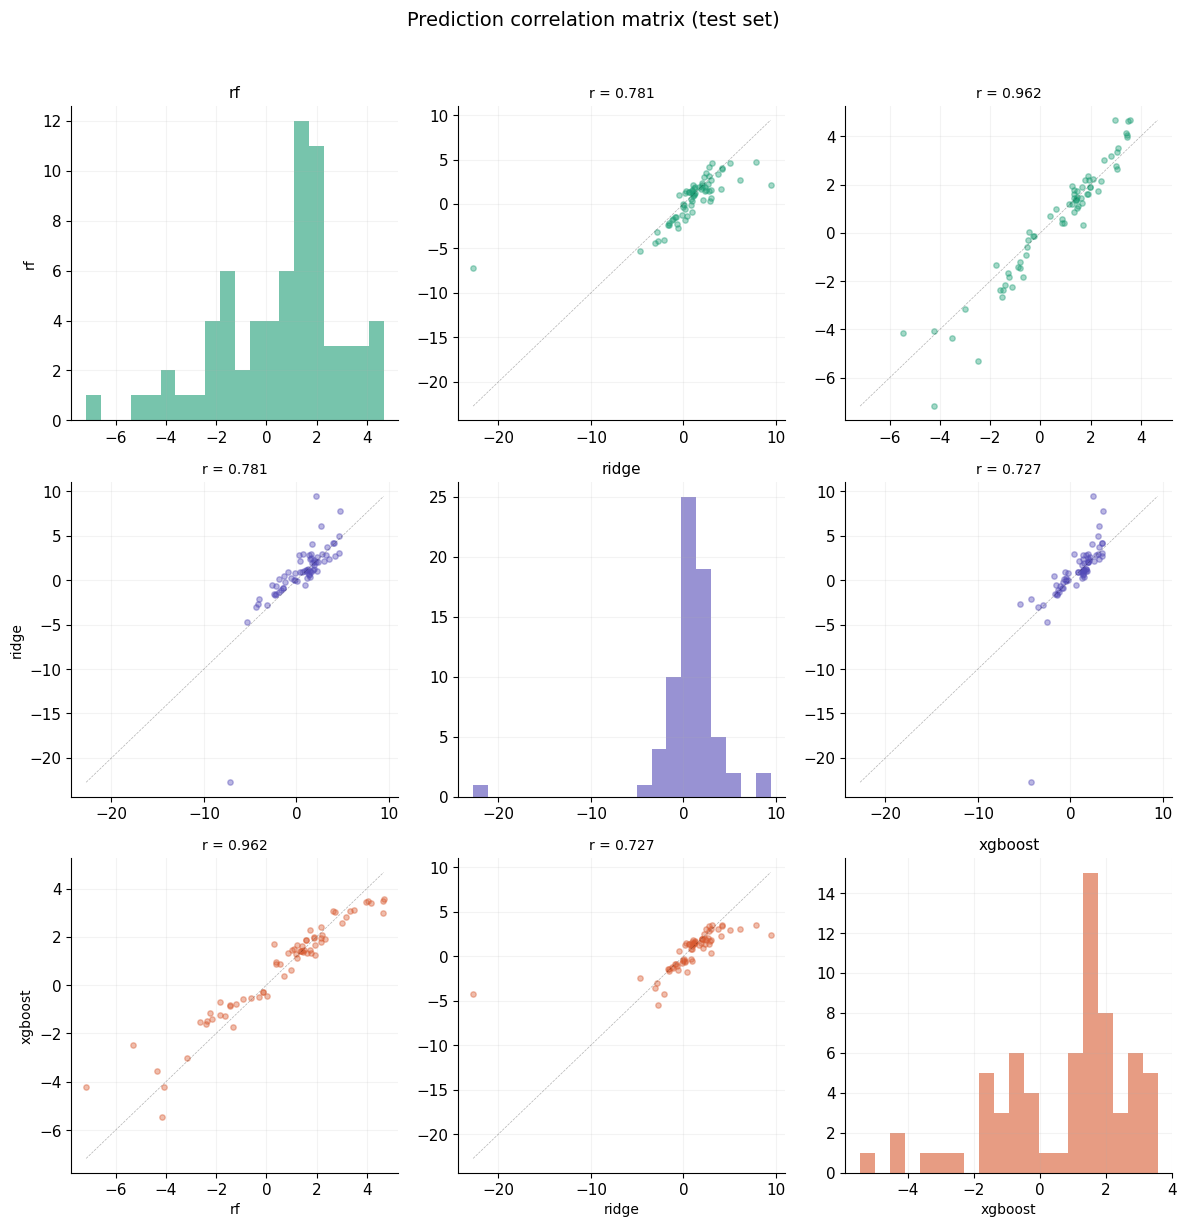


Prediction correlation (test set)
                         rf       ridge     xgboost
             rf       1.000       0.781       0.962
          ridge       0.781       1.000       0.727
        xgboost       0.962       0.727       1.000


In [9]:
from src.compare_prediction_correlation import compare_prediction_correlation
compare_prediction_correlation(results)

#### Key findings
- **RF and XGBoost are nearly identical** (r = 0.96) — both are tree-based models learning similar splits, so ensembling them provides minimal benefit
- **Ridge is genuinely different** (r = 0.78 with RF, r = 0.73 with XGBoost) — its linear structure captures different patterns

- **Ensembling models**: a weighted average of RF + Ridge (or XGBoost + Ridge) could improve predictions, since they make different errors on different samples
- The diagonal histograms confirm Ridge has a tighter, more concentrated prediction distribution compared to the tree-based models

## The Verdict

Combine all the evidence below to form overall view:

- accuracy metrics  
- overfitting behaviour  
- residual analysis  
- feature importance agreement  
- prediction correlation  

This helps to understand how the models behave from different angles, not just a single metric.

In [10]:
from src.final_verdict import print_final_verdict
print_final_verdict(results, shap_data)


                     FINAL MODEL COMPARISON                      

  Criterion                      Winner          Value          
  -------------------------------------------------------
  Best test R²                   rf              0.3486         
  Best test RMSE                 rf              4.051          
  Best test MAE                  rf              3.170          
  Best direction accuracy        rf              73.91%         
  Least overfitting              ridge                          

  Model           Top SHAP feature          SHAP value  
  --------------------------------------------------
  rf              VIX_Change                1.9143      
  ridge           VIX_Change                2.0315      
  xgboost         VIX_Change                1.6804      

  Model             Wins
  ----------------------
  rf                 4  ████
  ridge              1  █
  xgboost            0  

  Recommendation: rf (4/5 criteria)


### Summary

| Evidence | Winner | Insight |
|----------|--------|---------|
| Test accuracy (R², RMSE, MAE) | RF | Marginally best, but all models are close |
| Direction accuracy | RF | 73.9% — gets the sign right 3 out of 4 times |
| Overfitting resistance | Ridge | Most stable train→test, most trustworthy |
| Feature consensus | All agree | VIX is #1, pushes S&P DOWN. GDP pushes UP. |
| Train vs test importance | All flagged | VIX is over-relied upon during training |
| Ensemble potential | RF + Ridge | Different architectures capture different patterns |

### Future works
1. **RF is the primary model** — best test performance across 4 of 5 criteria
2. **Need to consider RF + Ridge ensemble** — their low correlation (r=0.78) suggests blending could reduce variance
3. **VIX dominance is real but risky** — 60-69% concentration on one feature means model performance depends heavily on VIX being predictive in future regimes
4. **Need to consider adding features** — the remaining 6 features contribute only 30-37% combined. Additional macro signals (yield curve slope, earnings momentum, sentiment) could reduce VIX dependency

5. **Increace test samples size** — validate with walk-forward cross-validation